# Zynema

## Download Dataset

In [3]:
import gdown
import os

file_id = "1KTB_JuCZliV82zg78esxhm3ebt6kbgNx"
output_file = "NetflixOriginals.csv"

if not os.path.exists(output_file):
    print("Downloading from Google Drive...")
    url = f"https://drive.google.com/uc?id={file_id}"
    gdown.download(url, output_file, quiet=False)
else:
    print("Dataset already exists, skipping...")

Dataset already exists, skipping...


## Load Library

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re, json, time, requests
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('NetflixOriginals.csv', encoding='latin1')
print(f'Shape: {df.shape}')
df.head(3)

Shape: (584, 6)


,Title,Genre,Premiere,Runtime,IMDB Score,Language
0,Enter the Anime,Documentary,"August 5, 2019",58,2.5,English/Japanese
1,Dark Forces,Thriller,"August 21, 2020",81,2.6,Spanish
2,The App,Science fiction/Drama,"December 26, 2019",79,2.6,Italian


## EDA

In [5]:
df.info()
print('\nMissing Values:')
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 584 entries, 0 to 583
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Title       584 non-null    object 
 1   Genre       584 non-null    object 
 2   Premiere    584 non-null    object 
 3   Runtime     584 non-null    int64  
 4   IMDB Score  584 non-null    float64
 5   Language    584 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 27.5+ KB

Missing Values:
Title         0
Genre         0
Premiere      0
Runtime       0
IMDB Score    0
Language      0
dtype: int64


In [6]:
all_genres = []
for g in df['Genre'].dropna():
    genres = [x.strip() for x in g.split(',')]
    all_genres.extend(genres)

unique_genres = sorted(set(all_genres))
print(f'Total unique genres: {len(unique_genres)}')

Total unique genres: 115


## Data Cleaning

In [7]:
df_clean = df.copy()
df_clean.columns = df_clean.columns.str.strip()

df_clean['Genre'] = df_clean['Genre'].str.lower().str.strip()
df_clean['Title'] = df_clean['Title'].str.lower().str.strip()
df_clean['Language'] = df_clean['Language'].str.lower().str.strip()

df_clean['Genre'] = df_clean['Genre'].str.replace('/', ' ', regex=False)
df_clean['Genre'] = df_clean['Genre'].str.replace('-', ' ', regex=False)
df_clean['Genre'] = df_clean['Genre'].str.replace(r'\s+', ' ', regex=True).str.strip()
df_clean['Title'] = df_clean['Title'].str.replace(r'\s+', ' ', regex=True).str.strip()
df_clean['Language'] = df_clean['Language'].str.replace(r'\s+', ' ', regex=True).str.strip()

df_clean[['Title', 'Genre', 'Language']].head(3)

,Title,Genre,Language
0,enter the anime,documentary,english/japanese
1,dark forces,thriller,spanish
2,the app,science fiction drama,italian


## Genre Mapping

In [8]:
def map_to_parent_genre(genre_str):
    if pd.isna(genre_str):
        return []
    genre_lower = genre_str.lower()
    parent_mapping = {
        'action':      ['action', 'superhero', 'heist', 'spy', 'martial'],
        'adventure':   ['adventure', 'exploration'],
        'animation':   ['animation', 'animated', 'anime', 'stop motion', 'cgi'],
        'comedy':      ['comedy', 'dark comedy', 'black comedy', 'satire', 'slapstick', 'parody'],
        'documentary': ['documentary', 'making of', 'mockumentary', 'concert film'],
        'drama':       ['drama', 'biopic', 'historical', 'sports', 'coming of age', 'biographical', 'crime drama'],
        'family':      ['family', 'christmas', 'holiday', 'kids'],
        'fantasy':     ['fantasy', 'magical', 'mythology'],
        'horror':      ['horror', 'zombie', 'supernatural horror', 'psychological horror'],
        'musical':     ['musical', 'concert', 'dance'],
        'mystery':     ['mystery', 'detective'],
        'romance':     ['romance', 'romantic', 'love'],
        'scifi':       ['science fiction', 'sci fi'],
        'thriller':    ['thriller'],
        'war':         ['war', 'military'],
        'western':     ['western'],
    }
    matched = []
    for parent, keywords in parent_mapping.items():
        for kw in keywords:
            if kw in genre_lower:
                matched.append(parent)
                break
    return list(set(matched)) if matched else ['other']

df_clean['parent_genre'] = df_clean['Genre'].apply(map_to_parent_genre)
df_clean['parent_genre_str'] = df_clean['parent_genre'].apply(lambda x: ', '.join(x))

df_clean[['Title', 'Genre', 'parent_genre_str']].head(3)

,Title,Genre,parent_genre_str
0,enter the anime,documentary,documentary
1,dark forces,thriller,thriller
2,the app,science fiction drama,"scifi, drama"


## Feature Engineering

In [9]:
def create_metadata(row):
    title = str(row['Title']).strip() if pd.notna(row['Title']) else 'unknown'
    genre = str(row['parent_genre_str']).strip() if pd.notna(row['parent_genre_str']) else 'unknown'
    language = str(row['Language']).strip() if pd.notna(row['Language']) else 'unknown'
    return f"movie title is {title}. genre is {genre}. language is {language}."

df_clean['metadata'] = df_clean.apply(create_metadata, axis=1)

df_clean['year'] = df_clean['Premiere'].str.extract(r'(\d{4})').astype(float)

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df_clean['runtime_normalized'] = scaler.fit_transform(df_clean[['Runtime']])

df_clean['primary_language'] = df_clean['Language'].str.split('/').str[0].str.strip()
df_clean['all_languages'] = df_clean['Language'].str.split('/').apply(
    lambda x: [l.strip() for l in x] if isinstance(x, list) else []
)

df_clean[['Title', 'year', 'Runtime', 'runtime_normalized', 'primary_language']].head(3)

,Title,year,Runtime,runtime_normalized,primary_language
0,enter the anime,2019.0,58,0.263415,english
1,dark forces,2020.0,81,0.375610,spanish
2,the app,2019.0,79,0.365854,italian


## Visualization

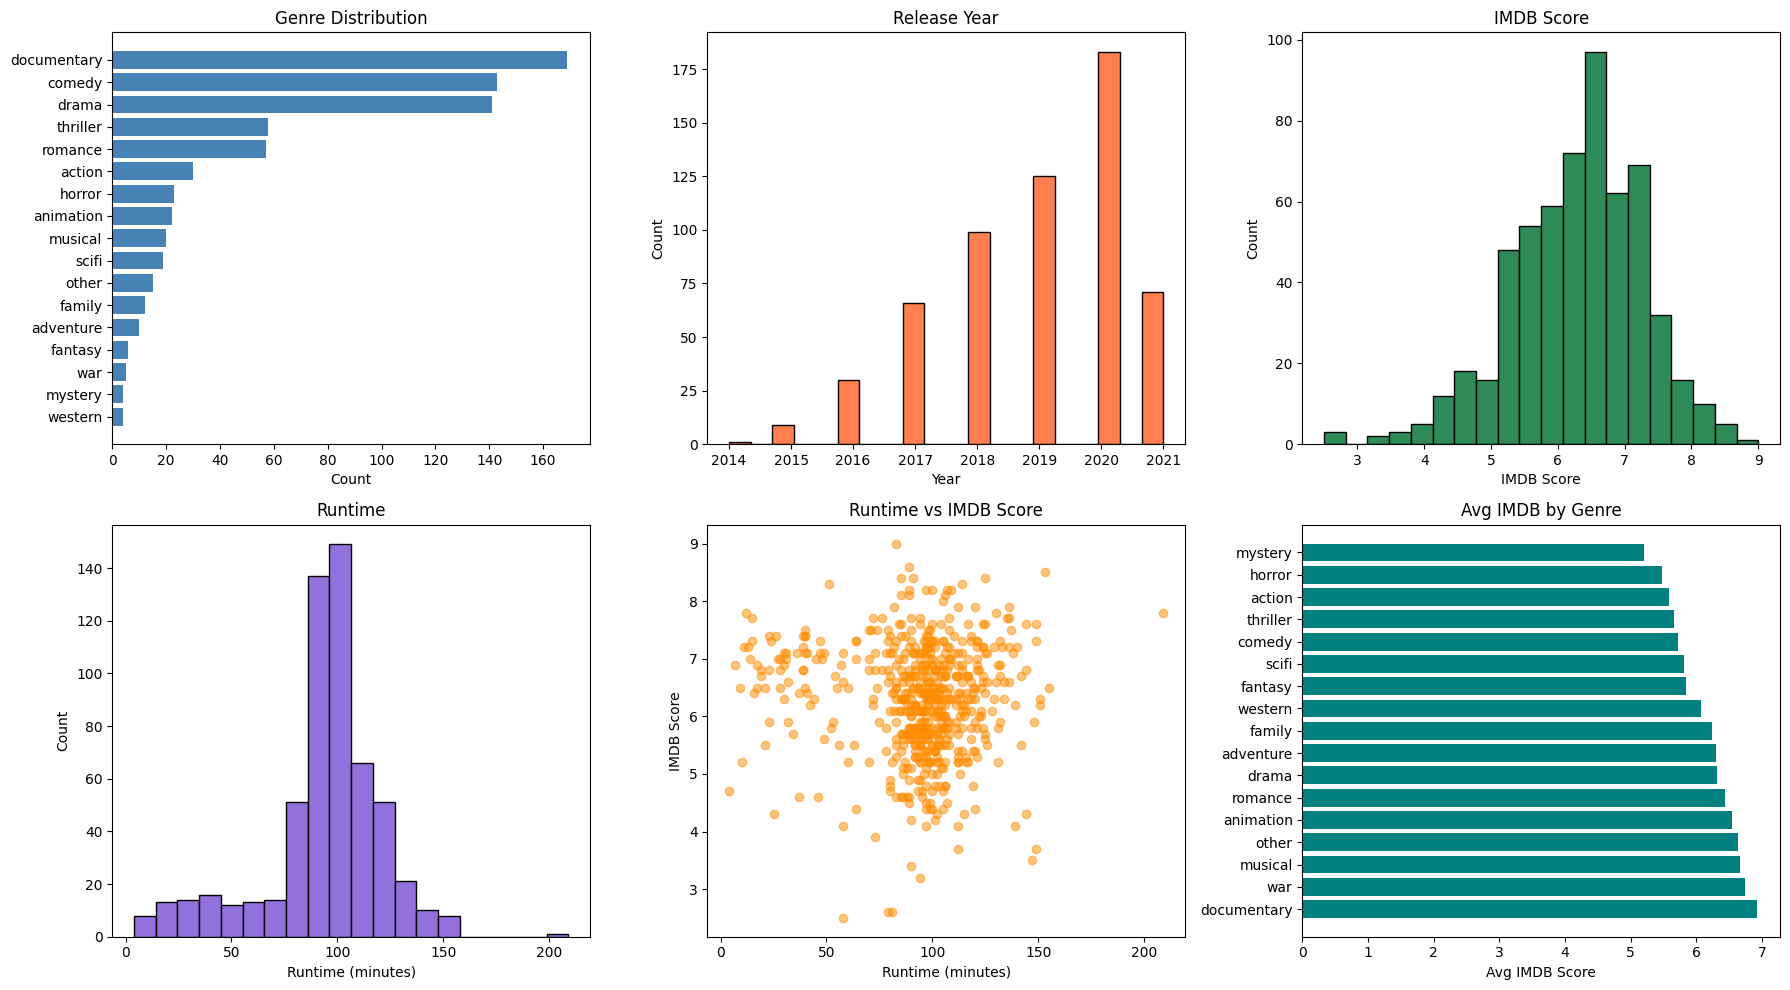

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

genre_counts = df_clean['parent_genre_str'].str.split(', ').explode().value_counts()
axes[0, 0].barh(genre_counts.index, genre_counts.values, color='steelblue')
axes[0, 0].set_xlabel('Count')
axes[0, 0].set_title('Genre Distribution')
axes[0, 0].invert_yaxis()

axes[0, 1].hist(df_clean['year'].dropna(), bins=20, color='coral', edgecolor='black')
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_title('Release Year')

axes[0, 2].hist(df_clean['IMDB Score'].dropna(), bins=20, color='seagreen', edgecolor='black')
axes[0, 2].set_xlabel('IMDB Score')
axes[0, 2].set_ylabel('Count')
axes[0, 2].set_title('IMDB Score')

axes[1, 0].hist(df_clean['Runtime'].dropna(), bins=20, color='mediumpurple', edgecolor='black')
axes[1, 0].set_xlabel('Runtime (minutes)')
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_title('Runtime')

axes[1, 1].scatter(df_clean['Runtime'], df_clean['IMDB Score'], alpha=0.5, color='darkorange')
axes[1, 1].set_xlabel('Runtime (minutes)')
axes[1, 1].set_ylabel('IMDB Score')
axes[1, 1].set_title('Runtime vs IMDB Score')

genre_imdb = df_clean.groupby(df_clean['parent_genre_str'].str.split(', ').str[0])['IMDB Score'].mean().sort_values(ascending=True)
axes[1, 2].barh(genre_imdb.index, genre_imdb.values, color='teal')
axes[1, 2].set_xlabel('Avg IMDB Score')
axes[1, 2].set_title('Avg IMDB by Genre')
axes[1, 2].invert_yaxis()

plt.tight_layout()
plt.show()

## Merge Poster (Optional)

In [11]:
try:
    from google.colab import files
    uploaded_old = files.upload()
    df_old = pd.read_csv(list(uploaded_old.keys())[0])
    if 'poster' in df_old.columns:
        old_posters = dict(zip(df_old['Title'].str.lower(), df_old['poster']))
        merged, reused = [], 0
        for title in df_clean['Title']:
            if title in old_posters and pd.notna(old_posters.get(title)):
                merged.append(old_posters[title])
                reused += 1
            else:
                merged.append(None)
        df_clean['poster'] = merged
        print(f"Reused: {reused} | Need fetch: {len(df_clean) - reused}")
    else:
        df_clean['poster'] = None
except:
    df_clean['poster'] = None
    print("No old dataset, will fetch all posters")

Saving netflix_cleaned (1).csv to netflix_cleaned (1).csv
Reused: 529 | Need fetch: 55


## Fetch Poster

In [12]:
API_KEY = '41e7b2e3'

def get_poster_omdb(title, retries=3, delay=1.1):
    url = 'https://www.omdbapi.com/'
    for _ in range(retries):
        try:
            params = {'apikey': API_KEY, 't': title}
            r = requests.get(url, params=params, timeout=10)
            if r.status_code == 200:
                data = r.json()
                if data.get('Response') == 'True':
                    poster = data.get('Poster')
                    if poster and poster != 'N/A':
                        return poster
                time.sleep(delay * 2)
            else:
                time.sleep(delay * 2)
        except:
            time.sleep(delay * 2)
    return None

to_fetch = df_clean[df_clean['poster'].isna()].copy()
print(f"Total: {len(df_clean)} | Already have: {len(df_clean) - len(to_fetch)} | Need fetch: {len(to_fetch)}")

success = 0
failed = 0

for i, (_, row) in enumerate(to_fetch.iterrows(), 1):
    poster = get_poster_omdb(row['Title'])
    df_clean.loc[row.name, 'poster'] = poster
    success += 1 if poster else 0
    failed += 1 if not poster else 0
    if i % 10 == 0 or i == len(to_fetch):
        print(f"Progress: {i}/{len(to_fetch)} | Success: {success} | Failed: {failed}")
    time.sleep(1.1)

print(f"Done. Success: {success} | Failed: {failed}")

Total: 584 | Already have: 529 | Need fetch: 55
Progress: 10/55 | Success: 0 | Failed: 10
Progress: 20/55 | Success: 0 | Failed: 20
Progress: 30/55 | Success: 0 | Failed: 30
Progress: 40/55 | Success: 0 | Failed: 40
Progress: 50/55 | Success: 0 | Failed: 50
Progress: 55/55 | Success: 0 | Failed: 55
Done. Success: 0 | Failed: 55


## Validate Poster

In [13]:
def check_poster_url(url):
    if not url:
        return False
    try:
        return requests.head(url, timeout=5).status_code == 200
    except:
        return False

df_clean['poster_valid'] = df_clean['poster'].apply(check_poster_url)
before = len(df_clean)
df_clean = df_clean[df_clean['poster_valid']].drop(columns=['poster_valid']).reset_index(drop=True)

print(f"Valid: {len(df_clean)} | Removed: {before - len(df_clean)}")

Valid: 529 | Removed: 55


## Export

In [16]:
df_export = df_clean[['Title', 'parent_genre_str', 'metadata',
                       'poster', 'year', 'IMDB Score', 'Runtime', 'runtime_normalized',
                       'primary_language', 'Premiere']].copy()

df_export.to_csv('netflix_cleaned.csv', index=False)

all_genre_names = [
    'action', 'adventure', 'animation', 'comedy', 'documentary',
    'drama', 'family', 'fantasy', 'horror', 'musical',
    'mystery', 'romance', 'scifi', 'thriller', 'war',
    'western', 'other'
]
categories_json = [{'id': i+1, 'name': cat} for i, cat in enumerate(sorted(all_genre_names))]
with open('categories.json', 'w') as f:
    json.dump(categories_json, f, indent=2)

print(f"Total film: {len(df_export)}")
print(f"Columns: {list(df_export.columns)}")

files.download('netflix_cleaned.csv')
files.download('categories.json')

Total film: 529
Columns: ['Title', 'parent_genre_str', 'metadata', 'poster', 'year', 'IMDB Score', 'Runtime', 'runtime_normalized', 'primary_language', 'Premiere']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>